In [25]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from tqdm import tqdm
from PIL import Image
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.signal import wiener

In [26]:
sns.set(style="whitegrid")

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(10,4))
    counts = df["sentiment"].value_counts().sort_index()
    names = ["Negative","Moderate","Positive"]
    colors = ["red","gray","green"]

    bars = plt.bar(names, counts.values, color=colors)

    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x()+bar.get_width()/2, val+10, str(val),
                 ha="center", va="bottom", fontsize=12)

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [27]:
AUG_SAVE_DIR = "Data/Augmented_Sentiment"
os.makedirs(AUG_SAVE_DIR, exist_ok=True)

def aug_noise(audio):
    return audio + np.random.normal(0, 0.005, len(audio))

def aug_gain(audio):
    return audio * np.random.uniform(0.8, 1.2)

def aug_pitch(audio, sr=16000):
    steps = np.random.uniform(-1.5, 1.5)
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

AUGS = [aug_noise, aug_gain, aug_pitch]


def augment_and_balance_sentiment(df):
    print("\n===============================")
    print("BALANCING SENTIMENTS BY AUGMENTATION")
    print("===============================\n")

    sentiment_counts = df["sentiment"].value_counts()
    target = sentiment_counts.max()

    print("Before balancing:")
    print(sentiment_counts)

    new_rows = []

    for sentiment, count in sentiment_counts.items():

        needed = target - count
        print(f"\nSentiment {sentiment}: {count} → need {needed} extra")

        if needed <= 0:
            continue

        group = df[df["sentiment"] == sentiment]

        for _ in tqdm(range(needed)):
            row = group.sample(1).iloc[0]

            audio, sr = librosa.load(row["path"], sr=16000)

            aug_fn = random.choice(AUGS)
            audio_aug = aug_fn(audio)

            fname = f"{row['emotion_lb']}_sent{sentiment}_AUG_{random.randint(0,999999)}.wav"
            out_path = os.path.join(AUG_SAVE_DIR, fname)

            sf.write(out_path, audio_aug, 16000)

            new_rows.append({
                "dataset": row["dataset"],
                "path": out_path,
                "emotion_lb": row["emotion_lb"],
                "sentiment": sentiment
            })

    df_out = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
    df_out = df_out.sample(frac=1, random_state=42).reset_index(drop=True)

    print("\nAfter balancing:")
    print(df_out["sentiment"].value_counts())

    return df_out


In [ ]:
class AudioPreprocessor:
    def __init__(self, sr=16000, trim_db_first=30, trim_db_second=25):
        self.sr = sr
        self.trim_db_first = trim_db_first
        self.trim_db_second = trim_db_second

    # ---------- Trim ----------
    def trim_audio(self, samples, top_db):
        trimmed, _ = librosa.effects.trim(samples, top_db=top_db)
        return trimmed

    # ---------- Spectral-Gating Denoise ----------
    def spectral_gate_denoise(self, samples, noise_reduction_db=12):
        n_fft = 1024
        hop = 256
        win = "hann"

        _, _, Zxx = stft(samples, fs=self.sr, nperseg=n_fft,
                         noverlap=n_fft - hop, window=win)

        mag = np.abs(Zxx)
        phase = np.angle(Zxx)

        noise_floor = np.percentile(mag, 10, axis=1, keepdims=True)
        reduction_factor = 10 ** (-noise_reduction_db / 20)
        mask = mag > (noise_floor * reduction_factor)
        mag_denoised = mag * mask

        Zxx_denoised = mag_denoised * np.exp(1j * phase)

        _, cleaned = istft(Zxx_denoised, fs=self.sr, nperseg=n_fft,
                           noverlap=n_fft - hop, window=win)

        return cleaned.astype(np.float32)

    # ---------- Waveform CMVN ----------
    def cmvn(self, samples):
        mean = np.mean(samples)
        std = np.std(samples) + 1e-8
        return (samples - mean) / std

    # ---------- Normalize waveform peak ----------
    def normalize(self, samples):
        max_amp = np.max(np.abs(samples))
        return samples / max_amp if max_amp > 0 else samples


In [29]:
def log_mel_spectrogram(audio, sr,
                        n_fft=1024, hop_length=128,
                        n_mels=128, eps=1e-10):

    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr,
        n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels
    )
    return librosa.power_to_db(mel + eps, ref=np.max)


def save_logmel(logmel, out_path):
    logmel = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-8)
    logmel = np.flipud(logmel)
    img = Image.fromarray((logmel*255).astype(np.uint8))
    img.save(out_path)
    return logmel.shape


In [30]:
def preprocess_and_split(df,
                         output_root="Data/Spectrograms",
                         metadata_csv="Data/spectrogram_metadata.csv",
                         seed=42):

    ap = AudioPreprocessor(sr=16000, denoise=True)
    folder_map = {-1:"Negative", 0:"Moderate", 1:"Positive"}
    metadata = []

    train_df, temp = train_test_split(
        df, test_size=0.30,
        stratify=df["sentiment"], random_state=seed
    )
    val_df, test_df = train_test_split(
        temp, test_size=0.50,
        stratify=temp["sentiment"], random_state=seed
    )

    splits = {"train":train_df, "val":val_df, "test":test_df}

    for split, split_df in splits.items():
        print(f"\nProcessing {split} ({len(split_df)})...")
        for _, row in split_df.iterrows():

            try:
                samples = ap.process(row["path"])
                logmel = log_mel_spectrogram(samples, ap.sr)

                out_dir = os.path.join(output_root, split, folder_map[row["sentiment"]])
                os.makedirs(out_dir, exist_ok=True)

                fname = os.path.splitext(os.path.basename(row["path"]))[0] + ".png"
                out_path = os.path.join(out_dir, fname)

                shape = save_logmel(logmel, out_path)

                metadata.append({
                    "path": out_path,
                    "sentiment": row["sentiment"],
                    "split": split,
                    "time_frames": shape
                })

            except Exception as e:
                print("Failed:", row["path"], e)
                gc.collect()

    pd.DataFrame(metadata).to_csv(metadata_csv, index=False)
    print("\nSaved metadata:", metadata_csv)


In [31]:
def check_saved_files(output_root="Data/Spectrograms"):
    report = {}
    for split in ["train","val","test"]:
        split_dir = os.path.join(output_root, split)
        if not os.path.exists(split_dir): continue
        report[split] = {
            c: len([f for f in os.listdir(os.path.join(split_dir,c)) if f.endswith(".png")])
            for c in os.listdir(split_dir)
        }

    print("\n=== SAVED FILES SUMMARY ===")
    for split, stats in report.items():
        print(f"\n[{split.upper()}]")
        for k,v in stats.items(): print(k,":",v)


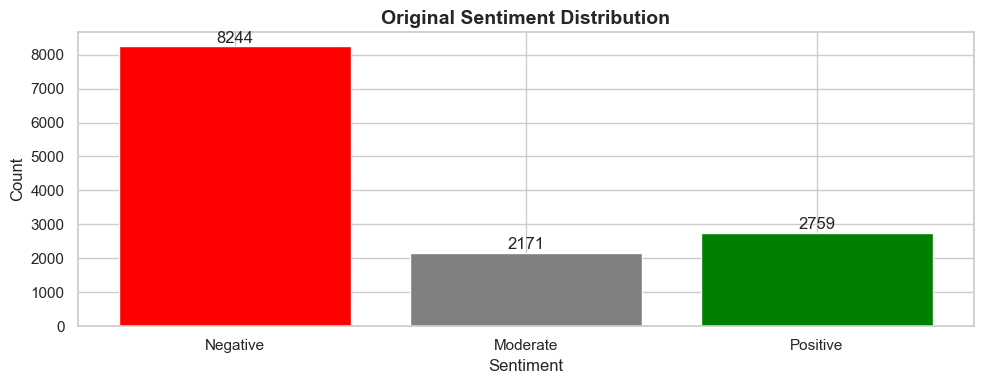


BALANCING SENTIMENTS BY AUGMENTATION

Before balancing:
sentiment
-1    8244
 1    2759
 0    2171
Name: count, dtype: int64

Sentiment -1: 8244 → need 0 extra

Sentiment 1: 2759 → need 5485 extra


100%|██████████| 5485/5485 [01:03<00:00, 86.94it/s] 



Sentiment 0: 2171 → need 6073 extra


100%|██████████| 6073/6073 [01:19<00:00, 76.37it/s] 



After balancing:
sentiment
-1    8244
 1    8244
 0    8244
Name: count, dtype: int64


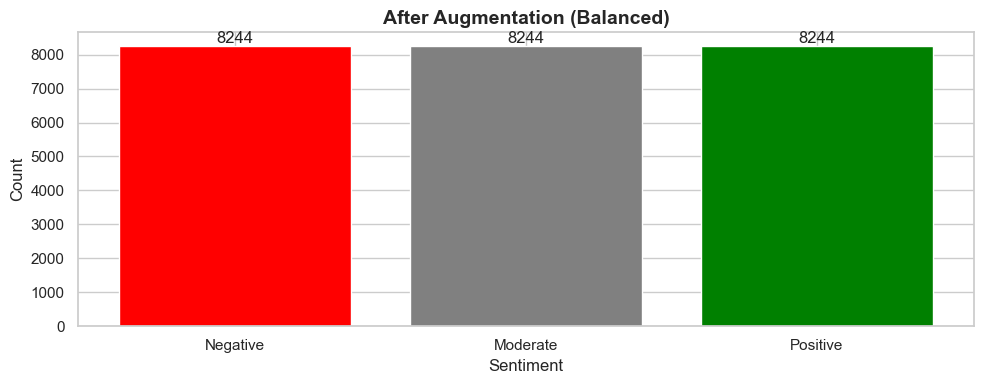


Processing train (17312)...


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\scipy\signal\_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\scipy\signal\_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)



Processing val (3710)...


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\scipy\signal\_signaltools.py:1783: RuntimeWarning: invalid value encountered in divide
  res *= (1 - noise / lVar)


Failed: Data\Dataset\CREMA\Actor_106\03-01-04-01-01-01-106_6188.wav Audio buffer is not finite everywhere

Processing test (3710)...

Saved metadata: Data/spectrogram_metadata.csv

=== SAVED FILES SUMMARY ===

[TRAIN]
Moderate : 5766
Negative : 5771
Positive : 5760

[VAL]
Moderate : 1236
Negative : 1235
Positive : 1237

[TEST]
Moderate : 1236
Negative : 1237
Positive : 1237


In [32]:
df = pd.read_csv("DataFrame/combined_grouped.csv")

plot_sentiment_distribution(df, "Original Sentiment Distribution")

df_bal = augment_and_balance_sentiment(df)
df_bal.to_csv("DataFrame/sentiment_balanced.csv", index=False)

plot_sentiment_distribution(df_bal, "After Augmentation (Balanced)")

preprocess_and_split(
    df_bal,
    output_root="Data/Spectrograms",
    metadata_csv="Data/spectrogram_metadata.csv"
)

check_saved_files("Data/Spectrograms")


In [41]:
import os
import numpy as np
import matplotlib.image as mpimg
from tensorflow.keras.utils import Sequence, to_categorical


class SentimentSpectrogramDataset(Sequence):

    _global_target_len = None   # shared global time length across all splits

    def __init__(self, root_dir, class_map,
                 split="train", batch_size=32,
                 shuffle=True, percentile=95,
                 for_lstm=True, force_shape=None,
                 return_paths=False):

        self.root_dir = os.path.join(root_dir, split)
        self.class_map = class_map
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.split = split
        self.for_lstm = for_lstm
        self.force_shape = force_shape
        self.return_paths = return_paths

        # Collect all samples
        self.samples = []
        for label_name, label_id in class_map.items():
            emo_dir = os.path.join(self.root_dir, label_name)
            if not os.path.exists(emo_dir):
                continue
            for fname in os.listdir(emo_dir):
                if fname.endswith(".png"):
                    self.samples.append((os.path.join(emo_dir, fname), label_id))

        # Compute or reuse global time dimension
        if SentimentSpectrogramDataset._global_target_len is None and split == "train":
            lengths = []
            for path, _ in self.samples:
                arr = mpimg.imread(path)
                if arr.ndim == 3:
                    arr = arr[..., :3].mean(axis=-1)
                lengths.append(arr.shape[1])
            SentimentSpectrogramDataset._global_target_len = int(
                np.percentile(lengths, percentile)
            )
            print(f"[INFO] Global target length = {SentimentSpectrogramDataset._global_target_len}")

        self.target_len = SentimentSpectrogramDataset._global_target_len
        print(f"[INFO] {split} will use target_len = {self.target_len}")

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size : (idx+1)*self.batch_size]
        X, Y, paths = [], [], []

        for path, class_id in batch:
            arr = mpimg.imread(path)

            # Convert RGB → grayscale if needed
            if arr.ndim == 3:
                arr = arr[..., :3].mean(axis=-1)

            n_mels, cur_time = arr.shape

            # Resize if force_shape enabled (rare)
            if self.force_shape is not None:
                tgt_time, tgt_mels = self.force_shape

                if n_mels != tgt_mels:
                    arr = np.resize(arr, (tgt_mels, cur_time))

                if cur_time > tgt_time:
                    arr = arr[:, :tgt_time]
                else:
                    arr = np.pad(arr, ((0,0),(0, tgt_time-cur_time)), mode="constant")

            else:
                # Normal pad/truncate only on time dimension
                if cur_time > self.target_len:
                    arr = arr[:, :self.target_len]
                else:
                    arr = np.pad(arr, ((0,0),(0, self.target_len-cur_time)), mode="constant")

            # Normalize 0–1
            arr = arr.astype("float32")
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

            if self.for_lstm:
                arr = arr.T  # (time, mel_bins)
            else:
                arr = np.expand_dims(arr, -1)  # (mel, time, 1)

            X.append(arr)
            Y.append(class_id)
            paths.append(path)

        X = np.array(X, dtype="float32")
        Y = to_categorical(Y, num_classes=len(self.class_map))

        if self.return_paths:
            return X, Y, paths
        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.samples)


In [42]:
from tensorflow.keras import layers, models

def build_cnn_rnn(max_time, n_mels, n_classes):

    inputs = layers.Input(shape=(max_time, n_mels))

    # CNN: Extract frequency patterns
    x = layers.Permute((2, 1))(inputs)  # (mel, time)
    x = layers.Reshape((n_mels, max_time, 1))(x)

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)

    # Flatten frequency, keep time
    freq_shape = x.shape[1] * x.shape[3]
    x = layers.Reshape((max_time, freq_shape))(x)

    # RNN temporal modeling
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.GRU(64))(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


In [43]:
def build_cnn_lstm(max_time, n_mels, n_classes):

    inputs = layers.Input(shape=(max_time, n_mels))

    x = layers.Permute((2,1))(inputs)
    x = layers.Reshape((n_mels, max_time, 1))(x)

    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,1))(x)

    flat_dim = x.shape[1] * x.shape[3]
    x = layers.Reshape((max_time, flat_dim))(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


In [44]:
def conv_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet_spectrogram(max_time, n_mels, n_classes):

    inputs = layers.Input(shape=(max_time, n_mels))
    x = layers.Permute((2,1))(inputs)
    x = layers.Reshape((n_mels, max_time, 1))(x)

    # ResNet-style blocks
    x = conv_block(x, 32, stride=1)
    x = conv_block(x, 32, stride=1)
    x = layers.MaxPooling2D((2,2))(x)

    x = conv_block(x, 64, stride=1)
    x = conv_block(x, 64, stride=1)
    x = layers.MaxPooling2D((2,2))(x)

    x = conv_block(x, 128, stride=1)
    x = conv_block(x, 128, stride=1)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(n_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


In [48]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import json

def train_model(model, train_ds, val_ds, save_path, max_epochs=100):

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    callbacks = [
        ModelCheckpoint(save_path, monitor="val_loss",
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_loss", patience=15,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=8, min_lr=1e-6)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks,
        verbose=1
    )

    # Save history
    with open(save_path.replace(".h5","_history.json"), "w") as f:
        json.dump({k:list(map(float, v)) for k,v in history.history.items()}, f)

    return history


In [46]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

def evaluate_model(model, test_ds, class_map):

    idx_to_class = [k for k,v in sorted(class_map.items(), key=lambda x:x[1])]
    n_classes = len(idx_to_class)

    y_true, y_pred, y_prob = [], [], []

    for X_batch, y_batch in test_ds:
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        y_prob.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_true, y_pred, target_names=idx_to_class))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=idx_to_class, yticklabels=idx_to_class)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC-AUC
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{idx_to_class[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],"k--")
    plt.title("ROC Curve per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


In [49]:
from tensorflow.keras.models import load_model
import pandas as pd

# -------------------------------------------------------------------
# Define sentiment classes and create datasets
# -------------------------------------------------------------------
sentiments = {"Negative": 0, "Moderate": 1, "Positive": 2}

print("Creating train dataset...")
train_ds = SentimentSpectrogramDataset(
    "Data/Spectrograms", sentiments,
    split="train", batch_size=32, shuffle=True, for_lstm=True
)

print("Creating validation dataset...")
val_ds = SentimentSpectrogramDataset(
    "Data/Spectrograms", sentiments,
    split="val", batch_size=32, shuffle=False, for_lstm=True
)

print("Creating test dataset...")
test_ds = SentimentSpectrogramDataset(
    "Data/Spectrograms", sentiments,
    split="test", batch_size=32, shuffle=False, for_lstm=True, return_paths=True
)

comparison_results = []

# -------------------------------------------------------------------
# Build models
# -------------------------------------------------------------------
print("Building CNN-RNN...")
model_cnn_rnn = build_cnn_rnn(max_time=train_ds.target_len,
                              n_mels=128,
                              n_classes=len(sentiments))
model_cnn_rnn.summary()

print("Building CNN-LSTM...")
model_cnn_lstm = build_cnn_lstm(max_time=train_ds.target_len,
                                n_mels=128,
                                n_classes=len(sentiments))
model_cnn_lstm.summary()

print("Building ResNet-Spectrogram...")
model_resnet = build_resnet_spectrogram(max_time=train_ds.target_len,
                                        n_mels=128,
                                        n_classes=len(sentiments))
model_resnet.summary()

# -------------------------------------------------------------------
# Train all models
# -------------------------------------------------------------------
print("\nTraining CNN-RNN...")
hist_rnn = train_model(model_cnn_rnn, train_ds, val_ds,
                       "Models/sentiment/cnn_rnn_best.h5")

print("\nTraining CNN-LSTM...")
hist_lstm = train_model(model_cnn_lstm, train_ds, val_ds,
                        "Models/sentiment/cnn_lstm_best.h5")

print("\nTraining ResNet...")
hist_res = train_model(model_resnet, train_ds, val_ds,
                       "Models/sentiment/resnet_best.h5")

# -------------------------------------------------------------------
# Load best models
# -------------------------------------------------------------------
cnn_rnn_best = load_model("Models/sentiment/cnn_rnn_best.h5")
cnn_lstm_best = load_model("Models/sentiment/cnn_lstm_best.h5")
resnet_best = load_model("Models/sentiment/resnet_best.h5")

# -------------------------------------------------------------------
# Evaluate
# -------------------------------------------------------------------
def get_accuracy(model, dataset):
    y_true = []
    y_pred = []
    for X, y in dataset:
        p = model.predict(X, verbose=0)
        y_true.extend(np.argmax(y, axis=1))
        y_pred.extend(np.argmax(p, axis=1))
    return np.mean(np.array(y_true) == np.array(y_pred))

acc_rnn = get_accuracy(cnn_rnn_best, val_ds)
acc_lstm = get_accuracy(cnn_lstm_best, val_ds)
acc_res = get_accuracy(resnet_best, val_ds)

# -------------------------------------------------------------------
# Build comparison table
# -------------------------------------------------------------------
comparison_results.append(["CNN-RNN", acc_rnn])
comparison_results.append(["CNN-LSTM", acc_lstm])
comparison_results.append(["CNN-ResNet", acc_res])

df_compare = pd.DataFrame(comparison_results,
                          columns=["Model", "Validation Accuracy"])

print("\n===== MODEL COMPARISON =====")
print(df_compare)


Creating train dataset...


KeyboardInterrupt: 

In [ ]:
import json
import matplotlib.pyplot as plt

def load_history(path):
    with open(path) as f:
        return json.load(f)

hist_rnn  = load_history("Models/sentiment/cnn_rnn_best_history.json")
hist_lstm = load_history("Models/sentiment/cnn_lstm_best_history.json")
hist_res  = load_history("Models/sentiment/resnet_best_history.json")

plt.figure(figsize=(14,5))

# ---------------- ACC ----------------
plt.subplot(1,2,1)
plt.plot(hist_rnn["accuracy"], label="CNN-RNN")
plt.plot(hist_lstm["accuracy"], label="CNN-LSTM")
plt.plot(hist_res["accuracy"], label="ResNet")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ---------------- LOSS ----------------
plt.subplot(1,2,2)
plt.plot(hist_rnn["loss"], label="CNN-RNN")
plt.plot(hist_lstm["loss"], label="CNN-LSTM")
plt.plot(hist_res["loss"], label="ResNet")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
import csv

def predict_to_csv(model, dataset, class_map, out_path="predictions.csv"):
    
    inv_map = {v:k for k,v in class_map.items()}
    rows = []

    for X, y, paths in SentimentSpectrogramDataset(
            "Data/Spectrograms", class_map, split="test",
            batch_size=32, for_lstm=True, return_paths=True):

        preds = model.predict(X, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = np.argmax(y, axis=1)

        for p, t, pr, probs in zip(paths, true_labels, pred_labels, preds):
            rows.append([
                p,
                inv_map[t],
                inv_map[pr],
                float(np.max(probs)),
                list(map(float, probs))
            ])

    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["file", "true", "pred", "confidence", "probabilities"])
        writer.writerows(rows)

    print(f"Saved predictions → {out_path}")


predict_to_csv(resnet_best, test_ds, sentiments,
               out_path="Models/sentiment/test_predictions.csv")


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

def grad_cam(model, spectrogram, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(spectrogram)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)[0]       # (H, W, C)
    weights = tf.reduce_mean(grads, axis=(0,1))    # (C)
    cam = tf.reduce_sum(tf.multiply(weights, conv_out[0]), axis=-1)

    cam = tf.maximum(cam, 0)
    cam = cam / tf.math.reduce_max(cam)

    return cam.numpy()


# Example Grad-CAM
sample, label, path = next(iter(
    SentimentSpectrogramDataset("Data/Spectrograms", sentiments,
                                split="test", batch_size=1,
                                return_paths=True)
))

cam = grad_cam(resnet_best, sample, layer_name="conv2d_3")

plt.figure(figsize=(10,4))
plt.imshow(sample[0].T, aspect="auto", cmap="magma")
plt.imshow(cam.T, cmap="jet", alpha=0.35, aspect="auto")
plt.title("Grad-CAM (ResNet)")
plt.colorbar()
plt.show()
